# Railway Defect RF-DETR Small — v10 Dataset Audit, Manual Split, Training & Colab Deployment

This notebook is designed for **Roboflow dataset version 9** where all exported images are intentionally placed in the original `train/` folder.

Pipeline:

```text
Roboflow v10 COCO export
        ↓
Dataset audit
  ├─ bounding boxes
  ├─ polygons / irregular shapes
  ├─ null/background images
  ├─ invalid annotations
  └─ duplicate / near-duplicate candidates
        ↓
Repair / normalize COCO annotations
        ↓
Our own 80 / 10 / 10 split
  ├─ train
  ├─ valid
  └─ test
        ↓
RF-DETR Small fine-tuning on Colab GPU
        ↓
checkpoint_best_total.pth
        ↓
Google Drive
        ↓
Dual-video railway inspection notebook
```

## Recommended Roboflow Version 9 settings

Before exporting v10:

### Split
- **Train: 100%**
- **Valid: 0%**
- **Test: 0%**

We split the dataset ourselves in this notebook.

### Preprocessing
- **Auto-Orient: ON**
- **Resize: OFF**
- **Grayscale: OFF**
- **Auto-Adjust Contrast: OFF**
- **Static Crop: OFF**
- **Tile: OFF for the first model**
- **Filter Null: OFF**
- Keep all required classes unchanged.

### Roboflow augmentation
- **None**
- Maximum version size: **1x**

RF-DETR applies training-time resizing/augmentation itself. We keep v10 as close to the source dataset as possible.

### Export format
Export as **COCO JSON**.

This notebook supports mixed annotations:
- normal bounding boxes
- COCO polygon segmentation
- polygon annotations with missing/invalid boxes (bbox is derived from the polygon)
- null/background images with no annotations

> Important: near-duplicate contrast/crop variants are intentionally **not removed**. They may appear across Train and Valid as requested. To keep the final evaluation more honest, the notebook tries to build the Test split mainly from images that are not detected as near-duplicate candidates.

In [ ]:
# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================================
# 2. INSTALL DEPENDENCIES
# ============================================================

# RF-DETR 1.9.4 supports current Colab/Python 3.13.
# We intentionally DO NOT install the legacy Roboflow Python SDK,
# because it currently requires Python < 3.13.
#
# Dataset access options supported below:
#   A) Upload/download a COCO ZIP and put it in Google Drive.
#   B) Paste Roboflow's direct dataset export URL.

!pip install -q \
    "rfdetr[train,augment,loggers]==1.9.4" \
    pycocotools \
    imagehash \
    iterative-stratification \
    pillow \
    opencv-python-headless \
    scikit-learn \
    matplotlib \
    pandas \
    requests \
    tqdm

print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 534.7/534.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.7/604.7 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.6/376.6 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# ============================================================
# 3. IMPORTS + GPU CHECK
# ============================================================

import os
import io
import gc
import json
import math
import hashlib
import random
import shutil
import zipfile
import requests
import warnings

from collections import Counter, defaultdict
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from tqdm.auto import tqdm

import torch
import imagehash

from sklearn.neighbors import NearestNeighbors
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

print("Python environment ready.")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
else:
    raise RuntimeError(
        "GPU is required for practical RF-DETR training. "
        "In Colab: Runtime -> Change runtime type -> GPU."
    )

Python environment ready.
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory (GB): 15.64


In [ ]:
# ============================================================
# 4. CONFIGURATION
# ============================================================

SEED = 42

# ------------------------------------------------------------
# DATASET SOURCE
# ------------------------------------------------------------
#
# Choose:
#   "drive_zip"  -> You downloaded/exported the COCO ZIP yourself
#                   and saved it to Google Drive.
#
#   "direct_url" -> Paste the private direct-download URL shown by
#                   Roboflow's "Download Dataset / Show Download Code".
#
DATASET_SOURCE = "direct_url"

# Option A: Google Drive ZIP path
DATASET_ZIP_PATH = Path(
    "/content/drive/MyDrive/Smart_Railway_AI/datasets/"
    "railway_defect_master_v3_v10_coco.zip"
)

# Option B: direct Roboflow export URL.
# Keep this private. Do not commit it to GitHub.
ROBOFLOW_DIRECT_EXPORT_URL = "https://app.roboflow.com/ds/96iYfR2Diy?key=ueS2oF5E41"

# ------------------------------------------------------------
# WORKING DIRECTORIES
# ------------------------------------------------------------

RAW_ROOT = Path("/content/railway_v10_raw")
MASTER_ROOT = Path("/content/railway_v10_master")
SPLIT_ROOT = Path("/content/railway_v10_rfdetr")

# Permanent model output
DRIVE_MODEL_DIR = Path(
    "/content/drive/MyDrive/Smart_Railway_AI/models/"
    "railway_defect_master_v3_rfdetr_small_v10"
)

# Local training output for faster writes during training.
LOCAL_TRAIN_OUTPUT = Path("/content/rfdetr_small_v10_output")

# ------------------------------------------------------------
# OUR OWN SPLIT
# ------------------------------------------------------------

TRAIN_RATIO = 0.80
VALID_RATIO = 0.10
TEST_RATIO  = 0.10

assert abs(TRAIN_RATIO + VALID_RATIO + TEST_RATIO - 1.0) < 1e-9

# ------------------------------------------------------------
# DUPLICATE AUDIT
# ------------------------------------------------------------

# pHash Hamming distance. 0 = visually identical hash.
# 6 is conservative for contrast/light editing candidates.
PHASH_DISTANCE_THRESHOLD = 6

# If True, near-duplicate candidates are preferentially excluded
# from TEST, while they remain allowed to cross TRAIN and VALID.
KEEP_TEST_MOSTLY_UNIQUE = True

# ------------------------------------------------------------
# RF-DETR
# ------------------------------------------------------------

MODEL_RESOLUTION = 512  # RF-DETR Small native/default resolution
MODEL_NAME = "RFDETRSmall"

# Automatically chosen later based on the number of training images.
EPOCHS_OVERRIDE = None
LR_OVERRIDE = None

# Disable resize->random-crop->resize scale jitter because railway
# defects may be close to image borders and the dataset already contains crops.
SCALE_JITTER = False

# Augmentation mode:
#   "auto" -> conservative when train <500 images, industrial otherwise
#   "industrial" -> always use RF-DETR inspection preset
#   "conservative" -> always use gentle preset
#   "default" -> RF-DETR torchvision default
AUGMENTATION_MODE = "auto"

random.seed(SEED)
np.random.seed(SEED)

print("Configuration loaded.")
print("Split:", TRAIN_RATIO, VALID_RATIO, TEST_RATIO)
print("Model:", MODEL_NAME, MODEL_RESOLUTION)

Configuration loaded.
Split: 0.8 0.1 0.1
Model: RFDETRSmall 512


In [ ]:
# ============================================================
# 5. ACQUIRE / EXTRACT THE COCO DATASET
# ============================================================

def reset_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

reset_dir(RAW_ROOT)

if DATASET_SOURCE == "drive_zip":
    if not DATASET_ZIP_PATH.exists():
        raise FileNotFoundError(
            f"Dataset ZIP not found:\n{DATASET_ZIP_PATH}\n\n"
            "Export Roboflow V10 as COCO JSON, save the ZIP there, "
            "or change DATASET_ZIP_PATH."
        )
    zip_path = DATASET_ZIP_PATH

elif DATASET_SOURCE == "direct_url":
    if not ROBOFLOW_DIRECT_EXPORT_URL.strip():
        raise ValueError(
            "ROBOFLOW_DIRECT_EXPORT_URL is empty. "
            "Paste the private direct download URL shown by Roboflow."
        )
    zip_path = Path("/content/railway_v10_download.zip")
    print("Downloading V10 export...")
    with requests.get(
        ROBOFLOW_DIRECT_EXPORT_URL,
        stream=True,
        timeout=180
    ) as response:
        response.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
else:
    raise ValueError("DATASET_SOURCE must be 'drive_zip' or 'direct_url'.")

print("Extracting:", zip_path)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(RAW_ROOT)

annotation_files = list(RAW_ROOT.rglob("_annotations.coco.json"))

if not annotation_files:
    raise FileNotFoundError(
        "No _annotations.coco.json was found. "
        "Make sure the dataset was exported as COCO JSON."
    )

print("\nCOCO annotation files found:")
for p in annotation_files:
    print(" -", p)

# Prefer the original Roboflow train folder because V10 should be 100% train.
train_candidates = [p for p in annotation_files if p.parent.name.lower() == "train"]

SOURCE_ANNOTATION_FILE = (
    train_candidates[0]
    if train_candidates
    else annotation_files[0]
)

SOURCE_IMAGE_DIR = SOURCE_ANNOTATION_FILE.parent

print("\nUsing:")
print("Annotation:", SOURCE_ANNOTATION_FILE)
print("Images:", SOURCE_IMAGE_DIR)

Extracting: /content/railway_v10_download.zip

COCO annotation files found:
 - /content/railway_v10_raw/train/_annotations.coco.json

Using:
Annotation: /content/railway_v10_raw/train/_annotations.coco.json
Images: /content/railway_v10_raw/train


In [ ]:
# ============================================================
# 6. LOAD COCO + BASIC DATASET AUDIT
# ============================================================

with open(SOURCE_ANNOTATION_FILE, "r", encoding="utf-8") as f:
    coco = json.load(f)

images = coco.get("images", [])
annotations = coco.get("annotations", [])
categories = coco.get("categories", [])

image_by_id = {img["id"]: img for img in images}
category_by_id = {cat["id"]: cat["name"] for cat in categories}

ann_by_image = defaultdict(list)
for ann in annotations:
    ann_by_image[ann["image_id"]].append(ann)

background_ids = [
    img["id"] for img in images
    if len(ann_by_image.get(img["id"], [])) == 0
]

class_counts = Counter(
    category_by_id.get(ann.get("category_id"), str(ann.get("category_id")))
    for ann in annotations
)

polygon_annotations = 0
bbox_only_annotations = 0
missing_bbox_annotations = 0

for ann in annotations:
    segmentation = ann.get("segmentation")
    has_polygon = (
        isinstance(segmentation, list)
        and len(segmentation) > 0
    )

    if has_polygon:
        polygon_annotations += 1
    else:
        bbox_only_annotations += 1

    if not ann.get("bbox") or len(ann.get("bbox", [])) != 4:
        missing_bbox_annotations += 1

print("=" * 70)
print("RAW DATASET AUDIT")
print("=" * 70)
print("Images:", len(images))
print("Annotations:", len(annotations))
print("Classes:", len(categories))
print("Background/null images:", len(background_ids))
print("Polygon-bearing annotations:", polygon_annotations)
print("BBox-only annotations:", bbox_only_annotations)
print("Missing/invalid bbox field:", missing_bbox_annotations)

print("\nClasses:")
for cat in categories:
    print(f"  {cat['id']:>3} -> {cat['name']}")

print("\nAnnotation counts:")
for name, count in class_counts.most_common():
    print(f"  {name:<35} {count}")

RAW DATASET AUDIT
Images: 2880
Annotations: 3592
Classes: 5
Background/null images: 322
Polygon-bearing annotations: 226
BBox-only annotations: 3366
Missing/invalid bbox field: 0

Classes:
    0 -> Railway-Defect-Master-v3
    1 -> Missing Fastener
    2 -> Missing Fishplate Bolt
    3 -> Rail Break
    4 -> Railway Joint Defect

Annotation counts:
  Missing Fastener                    1615
  Missing Fishplate Bolt              1310
  Rail Break                          545
  Railway Joint Defect                122


In [ ]:
# ============================================================
# 7. ANNOTATION REPAIR / NORMALIZATION
# ============================================================
#
# RF-DETR object detection trains on axis-aligned bounding boxes.
#
# Rules:
# 1. Keep valid COCO bbox annotations.
# 2. If bbox is missing but a polygon exists, derive bbox from polygon.
# 3. Clip bbox coordinates to the image boundaries.
# 4. Drop only annotations that cannot produce a positive-area bbox.
# 5. Preserve polygon segmentation data in the COCO JSON for audit.
# 6. Keep background/null images with zero annotations.

def polygon_points(segmentation):
    points = []

    if not isinstance(segmentation, list):
        return points

    for poly in segmentation:
        if not isinstance(poly, list) or len(poly) < 6:
            continue

        coords = np.asarray(poly, dtype=float).reshape(-1, 2)
        points.append(coords)

    return points


def bbox_from_polygons(segmentation):
    polygons = polygon_points(segmentation)

    if not polygons:
        return None

    pts = np.concatenate(polygons, axis=0)

    x_min = float(np.min(pts[:, 0]))
    y_min = float(np.min(pts[:, 1]))
    x_max = float(np.max(pts[:, 0]))
    y_max = float(np.max(pts[:, 1]))

    return [
        x_min,
        y_min,
        x_max - x_min,
        y_max - y_min
    ]


def clip_bbox_xywh(bbox, width, height):
    if bbox is None or len(bbox) != 4:
        return None

    x, y, w, h = map(float, bbox)

    x1 = max(0.0, min(float(width), x))
    y1 = max(0.0, min(float(height), y))
    x2 = max(0.0, min(float(width), x + w))
    y2 = max(0.0, min(float(height), y + h))

    w2 = x2 - x1
    h2 = y2 - y1

    if w2 <= 1e-6 or h2 <= 1e-6:
        return None

    return [x1, y1, w2, h2]


repaired_annotations = []

repair_stats = Counter()

polygon_bbox_disagreement = []

for ann in tqdm(annotations, desc="Checking annotations"):
    img = image_by_id.get(ann.get("image_id"))

    if img is None:
        repair_stats["missing_image_record"] += 1
        continue

    width = img.get("width")
    height = img.get("height")

    if not width or not height:
        image_path = SOURCE_IMAGE_DIR / img["file_name"]

        if not image_path.exists():
            repair_stats["missing_image_file"] += 1
            continue

        with Image.open(image_path) as im:
            width, height = im.size
            img["width"] = width
            img["height"] = height

    original_bbox = ann.get("bbox")
    polygon_bbox = bbox_from_polygons(ann.get("segmentation"))

    if original_bbox and len(original_bbox) == 4:
        candidate_bbox = original_bbox
        repair_stats["bbox_kept"] += 1
    elif polygon_bbox is not None:
        candidate_bbox = polygon_bbox
        repair_stats["bbox_derived_from_polygon"] += 1
    else:
        repair_stats["dropped_no_bbox_or_polygon"] += 1
        continue

    fixed_bbox = clip_bbox_xywh(candidate_bbox, width, height)

    if fixed_bbox is None:
        repair_stats["dropped_nonpositive_bbox"] += 1
        continue

    fixed = dict(ann)
    fixed["bbox"] = fixed_bbox
    fixed["area"] = float(fixed_bbox[2] * fixed_bbox[3])
    fixed["iscrowd"] = int(fixed.get("iscrowd", 0))
    repaired_annotations.append(fixed)

    # Compare stored bbox to polygon envelope where both are available.
    if original_bbox and polygon_bbox is not None:
        ob = np.asarray(original_bbox, dtype=float)
        pb = np.asarray(polygon_bbox, dtype=float)

        denom = max(float(pb[2] * pb[3]), 1.0)
        area_diff = abs(float(ob[2] * ob[3]) - float(pb[2] * pb[3])) / denom

        if area_diff > 0.20:
            polygon_bbox_disagreement.append({
                "annotation_id": ann.get("id"),
                "image_id": ann.get("image_id"),
                "class": category_by_id.get(ann.get("category_id")),
                "bbox_area_difference_ratio": area_diff,
            })

repaired_coco = {
    "info": coco.get("info", {}),
    "licenses": coco.get("licenses", []),
    "images": images,
    "annotations": repaired_annotations,
    "categories": categories,
}

reset_dir(MASTER_ROOT)

MASTER_ANNOTATION_FILE = MASTER_ROOT / "_annotations.coco.json"

with open(MASTER_ANNOTATION_FILE, "w", encoding="utf-8") as f:
    json.dump(repaired_coco, f, ensure_ascii=False)

print("\nRepair summary:")
for key, value in repair_stats.items():
    print(f"  {key:<35} {value}")

print(
    "\nPolygon/bbox area disagreements >20%:",
    len(polygon_bbox_disagreement)
)

if polygon_bbox_disagreement:
    display(pd.DataFrame(polygon_bbox_disagreement).head(20))

Checking annotations:   0%|          | 0/3592 [00:00<?, ?it/s]


Repair summary:
  bbox_kept                           3592

Polygon/bbox area disagreements >20%: 0


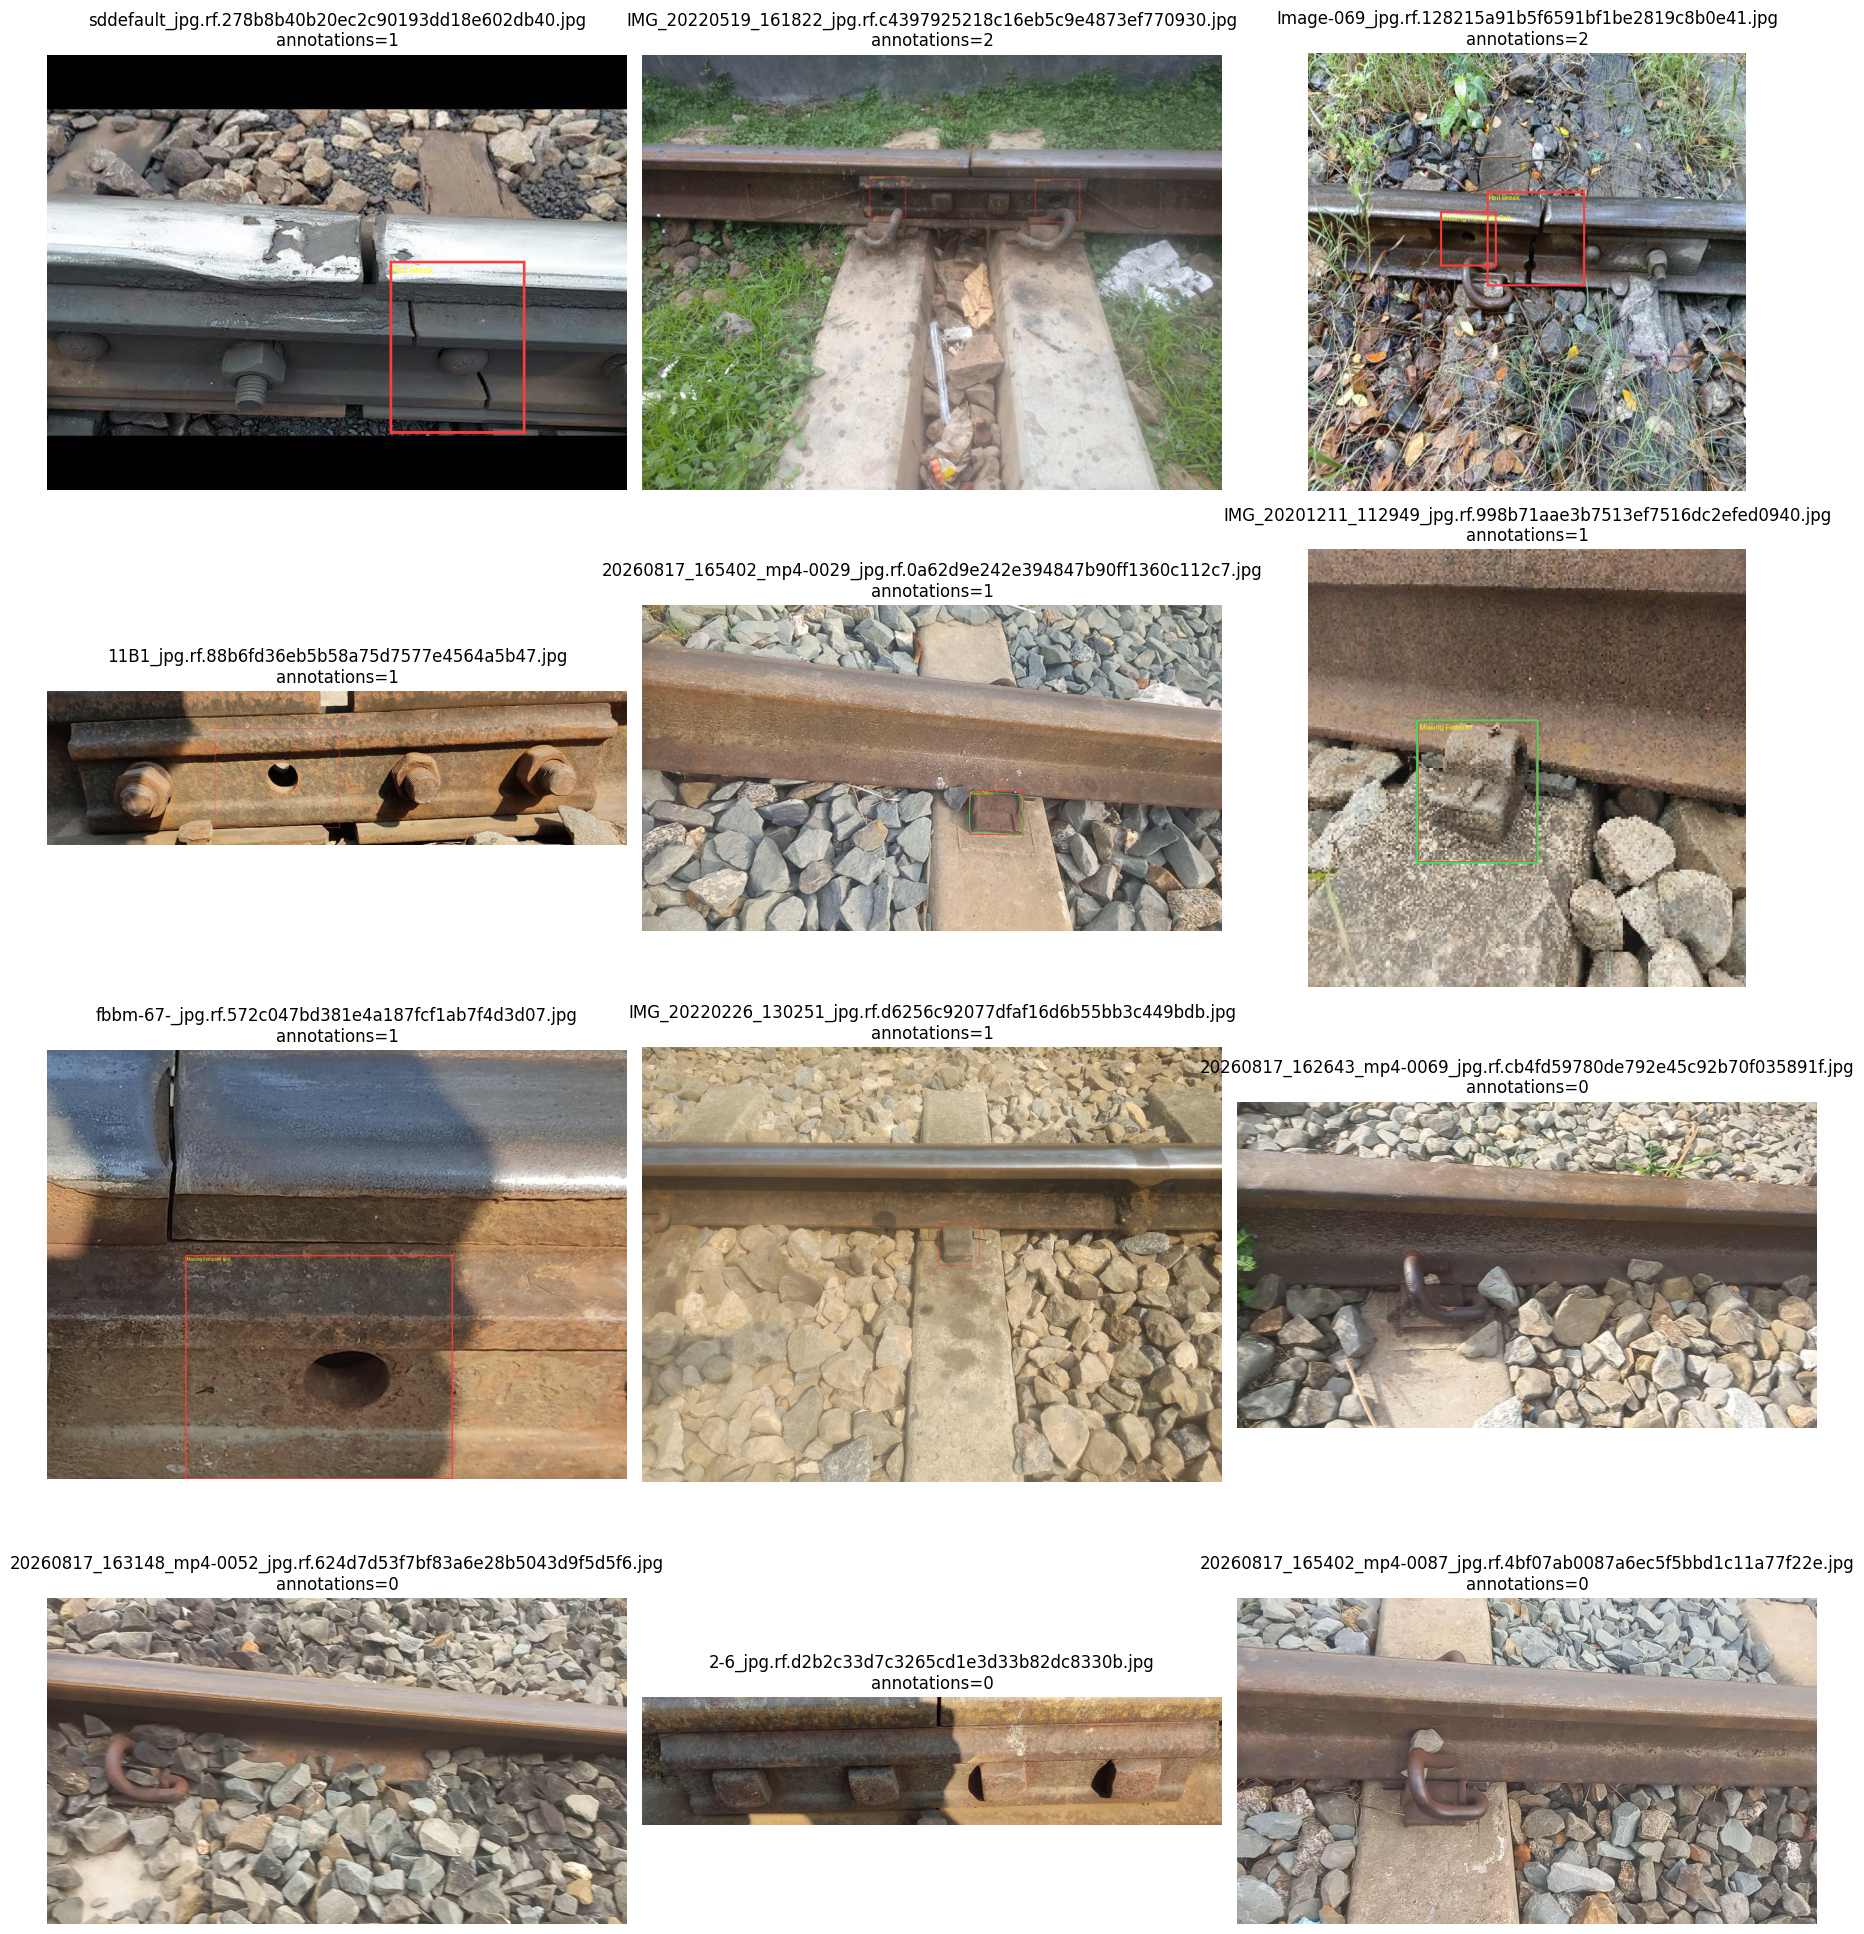

Legend:
  RED   = RF-DETR object-detection bounding box
  GREEN = source polygon outline, when present
  Images with annotations=0 are retained background/null examples.


In [ ]:
# ============================================================
# 8. VISUAL INSPECTION — BOXES, POLYGONS, BACKGROUNDS
# ============================================================

repaired_ann_by_image = defaultdict(list)

for ann in repaired_annotations:
    repaired_ann_by_image[ann["image_id"]].append(ann)


def draw_coco_sample(image_id):
    img_info = image_by_id[image_id]
    image_path = SOURCE_IMAGE_DIR / img_info["file_name"]

    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    anns = repaired_ann_by_image.get(image_id, [])

    for ann in anns:
        x, y, w, h = ann["bbox"]
        class_name = category_by_id.get(
            ann["category_id"],
            str(ann["category_id"])
        )

        # Bounding box
        draw.rectangle(
            [x, y, x + w, y + h],
            outline=(255, 60, 60),
            width=3
        )

        # Polygon outline, when present
        for polygon in polygon_points(ann.get("segmentation")):
            pts = [(float(px), float(py)) for px, py in polygon]
            if len(pts) >= 3:
                draw.line(
                    pts + [pts[0]],
                    fill=(60, 220, 100),
                    width=3
                )

        draw.text(
            (x + 3, y + 3),
            class_name,
            fill=(255, 255, 0)
        )

    return image, len(anns)


annotated_ids = [
    img_id for img_id in image_by_id
    if repaired_ann_by_image.get(img_id)
]

null_ids = [
    img_id for img_id in image_by_id
    if not repaired_ann_by_image.get(img_id)
]

random.seed(SEED)

sample_ids = []

if annotated_ids:
    sample_ids += random.sample(
        annotated_ids,
        min(8, len(annotated_ids))
    )

if null_ids:
    sample_ids += random.sample(
        null_ids,
        min(4, len(null_ids))
    )

cols = 3
rows = math.ceil(len(sample_ids) / cols)

plt.figure(figsize=(18, max(6, rows * 5)))

for i, image_id in enumerate(sample_ids, start=1):
    image, ann_count = draw_coco_sample(image_id)

    plt.subplot(rows, cols, i)
    plt.imshow(image)
    plt.axis("off")

    img_name = image_by_id[image_id]["file_name"]
    plt.title(
        f"{img_name}\nannotations={ann_count}"
    )

plt.tight_layout()
plt.show()

print("Legend:")
print("  RED   = RF-DETR object-detection bounding box")
print("  GREEN = source polygon outline, when present")
print("  Images with annotations=0 are retained background/null examples.")

In [ ]:
# ============================================================
# 9. IMAGE FILE + BOX QUALITY REPORT
# ============================================================

quality_rows = []
missing_files = []

for img in tqdm(images, desc="Image quality audit"):
    path = SOURCE_IMAGE_DIR / img["file_name"]

    if not path.exists():
        missing_files.append(img["file_name"])
        continue

    img_anns = repaired_ann_by_image.get(img["id"], [])

    areas = []
    relative_areas = []

    image_area = max(float(img["width"] * img["height"]), 1.0)

    for ann in img_anns:
        _, _, w, h = ann["bbox"]
        area = float(w * h)
        areas.append(area)
        relative_areas.append(area / image_area)

    quality_rows.append({
        "image_id": img["id"],
        "file_name": img["file_name"],
        "width": img["width"],
        "height": img["height"],
        "annotation_count": len(img_anns),
        "is_background": len(img_anns) == 0,
        "min_box_relative_area": (
            min(relative_areas)
            if relative_areas
            else np.nan
        ),
        "max_box_relative_area": (
            max(relative_areas)
            if relative_areas
            else np.nan
        ),
    })

quality_df = pd.DataFrame(quality_rows)

print("Missing image files:", len(missing_files))
if missing_files:
    print(missing_files[:20])

print("\nImage dimensions:")
display(
    quality_df[["width", "height"]]
    .describe()
)

print("\nBackground/null:")
print(
    int(quality_df["is_background"].sum()),
    "/",
    len(quality_df)
)

small_box_rows = quality_df[
    quality_df["min_box_relative_area"].fillna(1.0) < 0.001
]

print(
    "\nImages containing a very small box (<0.1% of image area):",
    len(small_box_rows)
)

display(
    quality_df
    .sort_values("min_box_relative_area")
    .head(20)
)

Image quality audit:   0%|          | 0/2880 [00:00<?, ?it/s]

Missing image files: 0

Image dimensions:


,width,height
count,2880.000000,2880.000000
mean,1628.831944,1209.660417
std,1427.485183,1018.972297
min,95.000000,70.000000
25%,640.000000,640.000000
50%,640.000000,640.000000
75%,3040.250000,1562.500000
max,4032.000000,4079.000000



Background/null:
322 / 2880

Images containing a very small box (<0.1% of image area): 1


,image_id,file_name,width,height,annotation_count,is_background,min_box_relative_area,max_box_relative_area
2425,2425,IMG_5633_HEIC.rf.72efe680b47e52e4e6d354f6aaaea...,4032,3024,3,False,0.000900,0.009409
2163,2163,IMG_20220226_125947_jpg.rf.cf415779ab34c0b68a2...,4000,3000,5,False,0.001320,0.009627
238,238,images-29-_jpg.rf.8d1296decff04dfaf77fefba8e2b...,335,597,4,False,0.001779,0.042276
2617,2617,IMG_5638_HEIC.rf.d9ef9ee171b60d9bd99c20d94fd56...,4032,3024,2,False,0.001905,0.007684
1446,1446,disruption-on-the-railroad-and-railway-track-p...,1300,956,2,False,0.001910,0.002660
2708,2708,images-84-_jpg.rf.8c1a124105c44ac2baf5457934b6...,415,739,4,False,0.001954,0.013268
1023,1023,photo_32_2026-08-18_15-14-43_jpg.rf.84a9705cd9...,1280,960,4,False,0.002086,0.010627
1449,1449,aug_prefix_0_8442_jpg.rf.7028a07520761346b5f62...,640,640,5,False,0.002093,0.005596
268,268,photo_6_2026-08-18_15-14-42_jpg.rf.ac443cf4d12...,1280,960,2,False,0.002160,0.018017
2060,2060,images-34-_jpg.rf.a035dd365149fc0de50cf89919bf...,480,640,3,False,0.002250,0.009692


In [ ]:
# ============================================================
# 10. EXACT + PERCEPTUAL DUPLICATE AUDIT
# ============================================================
#
# We DO NOT delete duplicates.
#
# SHA-256 detects exact files.
# pHash detects many visually similar/contrast-edited candidates.
# Cropped variants may not always be found by pHash, so this is an audit,
# not a proof that every crop-duplicate was found.

hash_rows = []

for img in tqdm(images, desc="Computing image hashes"):
    path = SOURCE_IMAGE_DIR / img["file_name"]

    if not path.exists():
        continue

    with open(path, "rb") as f:
        sha = hashlib.sha256(f.read()).hexdigest()

    with Image.open(path) as im:
        ph = imagehash.phash(im.convert("RGB"))

    # imagehash is 64 bits for default hash_size=8
    ph_bits = np.unpackbits(
        np.array(
            [int(str(ph), 16)],
            dtype=">u8"
        ).view(np.uint8)
    )

    hash_rows.append({
        "image_id": img["id"],
        "file_name": img["file_name"],
        "sha256": sha,
        "phash": str(ph),
        "phash_bits": ph_bits,
    })

hash_df = pd.DataFrame(hash_rows)

exact_groups = (
    hash_df.groupby("sha256")["image_id"]
    .apply(list)
)

exact_duplicate_groups = [
    ids for ids in exact_groups
    if len(ids) > 1
]

print("Exact duplicate groups:", len(exact_duplicate_groups))

near_duplicate_pairs = []

if len(hash_df) >= 2:
    X = np.stack(hash_df["phash_bits"].to_numpy()).astype(np.float32)

    # sklearn Hamming distance is a fraction of differing bits.
    radius = PHASH_DISTANCE_THRESHOLD / X.shape[1]

    nn = NearestNeighbors(
        metric="hamming",
        algorithm="brute",
        n_jobs=-1
    )

    nn.fit(X)

    distances, indices = nn.radius_neighbors(
        X,
        radius=radius,
        return_distance=True
    )

    seen = set()

    for i, (dists, inds) in enumerate(zip(distances, indices)):
        for dist, j in zip(dists, inds):
            if i == j:
                continue

            pair = tuple(sorted((i, int(j))))

            if pair in seen:
                continue

            seen.add(pair)

            hamming_bits = int(round(float(dist) * X.shape[1]))

            near_duplicate_pairs.append({
                "image_id_a": int(hash_df.iloc[pair[0]]["image_id"]),
                "file_a": hash_df.iloc[pair[0]]["file_name"],
                "image_id_b": int(hash_df.iloc[pair[1]]["image_id"]),
                "file_b": hash_df.iloc[pair[1]]["file_name"],
                "phash_distance": hamming_bits,
            })

print(
    "Near-duplicate candidate pairs "
    f"(pHash <= {PHASH_DISTANCE_THRESHOLD} bits):",
    len(near_duplicate_pairs)
)

if near_duplicate_pairs:
    display(pd.DataFrame(near_duplicate_pairs).head(50))

duplicate_member_ids = set()

for group in exact_duplicate_groups:
    duplicate_member_ids.update(group)

for row in near_duplicate_pairs:
    duplicate_member_ids.add(row["image_id_a"])
    duplicate_member_ids.add(row["image_id_b"])

print("Images involved in duplicate/near-duplicate candidates:", len(duplicate_member_ids))
print("They will NOT be deleted.")

Computing image hashes:   0%|          | 0/2880 [00:00<?, ?it/s]

Exact duplicate groups: 1
Near-duplicate candidate pairs (pHash <= 6 bits): 837


,image_id_a,file_a,image_id_b,file_b,phash_distance
0,2,Image-542_jpg.rf.41dadda4c031973e692332b3859ec...,2815,Image-888_jpg.rf.a7f2424939dd941e261f4f32af7d8...,2
1,6,aug_prefix_0_2130_jpg.rf.6f64aec973607d67a2570...,733,aug_prefix_0_2130_jpg.rf.b5e6076ae61015afe73ca...,0
2,9,aug_prefix_0_9226_jpg.rf.e487ef4145a346dcbf02e...,723,aug_prefix_0_9582_jpg.rf.e06e63030a739ff7631bc...,0
3,14,images27-3_jpeg.rf.d33a223ad935881306e31082b2f...,34,images27-4_jpeg.rf.787099b44ebea42eb5d759cfd0d...,2
4,14,images27-3_jpeg.rf.d33a223ad935881306e31082b2f...,51,images27-2_jpeg.rf.04ed2276232e58ecbde677f0b87...,2
5,14,images27-3_jpeg.rf.d33a223ad935881306e31082b2f...,442,images27-5_jpeg.rf.ff0352a28881caa93c2b242ebef...,6
6,16,11-1_jpeg.rf.b777397b89536e58fd67e6bc4545d152.jpg,38,11_jpeg.rf.f87b1bae767c7f5f824855a00ac06d53.jpg,2
7,16,11-1_jpeg.rf.b777397b89536e58fd67e6bc4545d152.jpg,880,11-2_jpeg.rf.2b5b66071c6fda3d9025ce4501694032.jpg,2
8,16,11-1_jpeg.rf.b777397b89536e58fd67e6bc4545d152.jpg,902,11-3_jpeg.rf.de16d0cb08b0ffdeccf26ae7fdf8ac84.jpg,6
9,19,B-99-_jpg.rf.c2967f276fff5a020ebc940603521711.jpg,49,B-97-_jpg.rf.4daad57ffd53b83d2248bbbd4d90a25f.jpg,0


Images involved in duplicate/near-duplicate candidates: 664
They will NOT be deleted.


In [ ]:
# ============================================================
# 11. BUILD MULTI-LABEL TARGET MATRIX FOR STRATIFICATION
# ============================================================

# One binary column per defect class, plus one explicit background column.
category_ids = [cat["id"] for cat in categories]
category_index = {
    category_id: index
    for index, category_id in enumerate(category_ids)
}

all_image_ids = [img["id"] for img in images]

Y = np.zeros(
    (len(all_image_ids), len(category_ids) + 1),
    dtype=np.int8
)

for row_idx, image_id in enumerate(all_image_ids):
    anns = repaired_ann_by_image.get(image_id, [])

    if not anns:
        Y[row_idx, -1] = 1
        continue

    for ann in anns:
        category_id = ann["category_id"]

        if category_id in category_index:
            Y[row_idx, category_index[category_id]] = 1

image_id_to_row = {
    image_id: i
    for i, image_id in enumerate(all_image_ids)
}

print("Target matrix shape:", Y.shape)
print(
    "Background images represented:",
    int(Y[:, -1].sum())
)

Target matrix shape: (2880, 6)
Background images represented: 322


In [ ]:
# ============================================================
# 12. OUR OWN TRAIN / VALID / TEST SPLIT
# ============================================================
#
# Desired behavior:
# - Keep every image.
# - Keep background/null images.
# - Allow near-duplicate variants to cross Train and Valid.
# - Prefer a Test split composed of images that were NOT detected as
#   near-duplicate candidates.

def multilabel_holdout(ids, holdout_ratio, seed):
    ids = list(ids)

    if holdout_ratio <= 0:
        return ids, []

    if len(ids) < 10:
        # Safe fallback for tiny datasets.
        random.Random(seed).shuffle(ids)
        n_holdout = max(1, round(len(ids) * holdout_ratio))
        return ids[n_holdout:], ids[:n_holdout]

    rows = [image_id_to_row[i] for i in ids]
    y_sub = Y[rows]

    splitter = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=holdout_ratio,
        random_state=seed
    )

    idx_keep, idx_hold = next(
        splitter.split(
            np.zeros((len(ids), 1)),
            y_sub
        )
    )

    keep_ids = [ids[i] for i in idx_keep]
    hold_ids = [ids[i] for i in idx_hold]

    return keep_ids, hold_ids


all_ids_set = set(all_image_ids)

if KEEP_TEST_MOSTLY_UNIQUE:
    unique_test_candidates = sorted(
        all_ids_set - duplicate_member_ids
    )
else:
    unique_test_candidates = sorted(all_ids_set)

target_test_count = max(
    1,
    round(len(all_image_ids) * TEST_RATIO)
)

if len(unique_test_candidates) >= target_test_count:
    # Choose approximately the requested test size from unique candidates.
    holdout_fraction_within_candidates = min(
        0.95,
        target_test_count / len(unique_test_candidates)
    )

    _, test_ids = multilabel_holdout(
        unique_test_candidates,
        holdout_fraction_within_candidates,
        SEED + 1
    )

    # Correct rounding if needed.
    test_ids = test_ids[:target_test_count]
else:
    warnings.warn(
        "Too few unique images for the requested Test split. "
        "Test will include some duplicate candidates."
    )

    _, test_ids = multilabel_holdout(
        all_image_ids,
        TEST_RATIO,
        SEED + 1
    )

test_ids = set(test_ids)

remaining_ids = [
    image_id
    for image_id in all_image_ids
    if image_id not in test_ids
]

# Valid ratio relative to what remains.
valid_fraction_remaining = VALID_RATIO / (TRAIN_RATIO + VALID_RATIO)

train_ids, valid_ids = multilabel_holdout(
    remaining_ids,
    valid_fraction_remaining,
    SEED + 2
)

train_ids = set(train_ids)
valid_ids = set(valid_ids)

assert train_ids.isdisjoint(valid_ids)
assert train_ids.isdisjoint(test_ids)
assert valid_ids.isdisjoint(test_ids)

assert train_ids | valid_ids | test_ids == set(all_image_ids)

print("Train:", len(train_ids))
print("Valid:", len(valid_ids))
print("Test :", len(test_ids))

print("\nDuplicate-candidate images by split:")
print("  Train:", len(train_ids & duplicate_member_ids))
print("  Valid:", len(valid_ids & duplicate_member_ids))
print("  Test :", len(test_ids & duplicate_member_ids))

Train: 2310
Valid: 287
Test : 283

Duplicate-candidate images by split:
  Train: 587
  Valid: 77
  Test : 0


In [ ]:
# ============================================================
# 13. WRITE RF-DETR COCO SPLITS
# ============================================================

reset_dir(SPLIT_ROOT)

split_map = {
    "train": train_ids,
    "valid": valid_ids,
    "test": test_ids,
}


def write_coco_split(split_name, selected_ids):
    split_dir = SPLIT_ROOT / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    selected_ids = set(selected_ids)

    split_images = [
        img for img in images
        if img["id"] in selected_ids
    ]

    split_annotations = [
        ann for ann in repaired_annotations
        if ann["image_id"] in selected_ids
    ]

    for img in tqdm(
        split_images,
        desc=f"Copying {split_name}"
    ):
        src = SOURCE_IMAGE_DIR / img["file_name"]
        dst = split_dir / img["file_name"]

        if not src.exists():
            raise FileNotFoundError(src)

        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)

    split_coco = {
        "info": coco.get("info", {}),
        "licenses": coco.get("licenses", []),
        "images": split_images,
        "annotations": split_annotations,
        "categories": categories,
    }

    ann_path = split_dir / "_annotations.coco.json"

    with open(ann_path, "w", encoding="utf-8") as f:
        json.dump(
            split_coco,
            f,
            ensure_ascii=False
        )

    return {
        "split": split_name,
        "images": len(split_images),
        "annotations": len(split_annotations),
        "background_images": sum(
            1 for img in split_images
            if len(repaired_ann_by_image.get(img["id"], [])) == 0
        ),
    }


split_stats = []

for split_name, selected_ids in split_map.items():
    split_stats.append(
        write_coco_split(
            split_name,
            selected_ids
        )
    )

display(pd.DataFrame(split_stats))

print("\nRF-DETR dataset:")
print(SPLIT_ROOT)
print("\nExpected structure:")
print("  train/_annotations.coco.json")
print("  valid/_annotations.coco.json")
print("  test/_annotations.coco.json")

Copying train:   0%|          | 0/2310 [00:00<?, ?it/s]

Copying valid:   0%|          | 0/287 [00:00<?, ?it/s]

Copying test:   0%|          | 0/283 [00:00<?, ?it/s]

,split,images,annotations,background_images
0,train,2310,2862,255
1,valid,287,356,32
2,test,283,374,35



RF-DETR dataset:
/content/railway_v10_rfdetr

Expected structure:
  train/_annotations.coco.json
  valid/_annotations.coco.json
  test/_annotations.coco.json


In [ ]:
# ============================================================
# 14. VERIFY CLASS / BACKGROUND BALANCE AFTER SPLIT
# ============================================================

def split_class_report(split_name, ids):
    ids = set(ids)
    counts = Counter()
    backgrounds = 0

    for image_id in ids:
        anns = repaired_ann_by_image.get(image_id, [])

        if not anns:
            backgrounds += 1
            continue

        present = {
            category_by_id[ann["category_id"]]
            for ann in anns
        }

        for class_name in present:
            counts[class_name] += 1

    row = {
        "split": split_name,
        "images": len(ids),
        "background": backgrounds,
    }

    for cat in categories:
        row[cat["name"]] = counts.get(cat["name"], 0)

    return row


balance_df = pd.DataFrame([
    split_class_report("train", train_ids),
    split_class_report("valid", valid_ids),
    split_class_report("test", test_ids),
])

display(balance_df)

,split,images,background,Railway-Defect-Master-v3,Missing Fastener,Missing Fishplate Bolt,Rail Break,Railway Joint Defect
0,train,2310,255,0,1040,688,383,98
1,valid,287,32,0,130,86,48,12
2,test,283,35,0,145,93,26,11


In [ ]:
# ============================================================
# 15. REPORT NEAR-DUPLICATES THAT CROSS TRAIN / VALID
# ============================================================
#
# This is intentionally allowed because your contrast/crop variants
# may be useful in both Train and Valid.
#
# Important: this can make validation mAP look better than it would on
# completely unseen scenes. The Test split is therefore kept mostly unique.

split_of = {}

for image_id in train_ids:
    split_of[image_id] = "train"

for image_id in valid_ids:
    split_of[image_id] = "valid"

for image_id in test_ids:
    split_of[image_id] = "test"

cross_split_pairs = []

for row in near_duplicate_pairs:
    a = row["image_id_a"]
    b = row["image_id_b"]

    split_a = split_of.get(a)
    split_b = split_of.get(b)

    if split_a != split_b:
        item = dict(row)
        item["split_a"] = split_a
        item["split_b"] = split_b
        cross_split_pairs.append(item)

train_valid_pairs = [
    row for row in cross_split_pairs
    if {row["split_a"], row["split_b"]} == {"train", "valid"}
]

print("Near-duplicate candidate pairs crossing any split:", len(cross_split_pairs))
print("Near-duplicate candidate pairs crossing Train/Valid:", len(train_valid_pairs))

if train_valid_pairs:
    display(pd.DataFrame(train_valid_pairs).head(50))

Near-duplicate candidate pairs crossing any split: 171
Near-duplicate candidate pairs crossing Train/Valid: 171


,image_id_a,file_a,image_id_b,file_b,phash_distance,split_a,split_b
0,2,Image-542_jpg.rf.41dadda4c031973e692332b3859ec...,2815,Image-888_jpg.rf.a7f2424939dd941e261f4f32af7d8...,2,train,valid
1,14,images27-3_jpeg.rf.d33a223ad935881306e31082b2f...,34,images27-4_jpeg.rf.787099b44ebea42eb5d759cfd0d...,2,valid,train
2,14,images27-3_jpeg.rf.d33a223ad935881306e31082b2f...,51,images27-2_jpeg.rf.04ed2276232e58ecbde677f0b87...,2,valid,train
3,14,images27-3_jpeg.rf.d33a223ad935881306e31082b2f...,442,images27-5_jpeg.rf.ff0352a28881caa93c2b242ebef...,6,valid,train
4,16,11-1_jpeg.rf.b777397b89536e58fd67e6bc4545d152.jpg,880,11-2_jpeg.rf.2b5b66071c6fda3d9025ce4501694032.jpg,2,train,valid
5,16,11-1_jpeg.rf.b777397b89536e58fd67e6bc4545d152.jpg,902,11-3_jpeg.rf.de16d0cb08b0ffdeccf26ae7fdf8ac84.jpg,6,train,valid
6,27,6_jpeg.rf.f354477307714cb0979085fdbf85ba3b.jpg,213,6-1_jpeg.rf.05d1c81cb4bc272edf2cf46d1c454f8d.jpg,2,valid,train
7,27,6_jpeg.rf.f354477307714cb0979085fdbf85ba3b.jpg,393,6-2_jpeg.rf.44f39fc6bce86e00311ba2e73e18accf.jpg,4,valid,train
8,27,6_jpeg.rf.f354477307714cb0979085fdbf85ba3b.jpg,892,6-4_jpeg.rf.1604a49c12ffa5972f87562729f8cfc7.jpg,4,valid,train
9,32,images3924_jpeg.rf.24c61ccd1593485b310b6742e89...,680,images3927_jpeg.rf.357e4ea00e604887d0782b8d6b1...,6,train,valid


In [ ]:
# ============================================================
# REMOVE UNUSED / EMPTY COCO CATEGORIES
# ============================================================

import json
from pathlib import Path
from collections import Counter

split_root = Path("/content/railway_v10_rfdetr")

for split_name in ["train", "valid", "test"]:
    json_path = (
        split_root /
        split_name /
        "_annotations.coco.json"
    )

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # IDs actually referenced by annotations
    used_category_ids = {
        ann["category_id"]
        for ann in data["annotations"]
    }

    before = [
        (cat["id"], cat["name"])
        for cat in data["categories"]
    ]

    data["categories"] = [
        cat
        for cat in data["categories"]
        if cat["id"] in used_category_ids
    ]

    after = [
        (cat["id"], cat["name"])
        for cat in data["categories"]
    ]

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(
            data,
            f,
            ensure_ascii=False
        )

    print(f"\n{split_name.upper()}")
    print("Before:", before)
    print("After :", after)


TRAIN
Before: [(0, 'Railway-Defect-Master-v3'), (1, 'Missing Fastener'), (2, 'Missing Fishplate Bolt'), (3, 'Rail Break'), (4, 'Railway Joint Defect')]
After : [(1, 'Missing Fastener'), (2, 'Missing Fishplate Bolt'), (3, 'Rail Break'), (4, 'Railway Joint Defect')]

VALID
Before: [(0, 'Railway-Defect-Master-v3'), (1, 'Missing Fastener'), (2, 'Missing Fishplate Bolt'), (3, 'Rail Break'), (4, 'Railway Joint Defect')]
After : [(1, 'Missing Fastener'), (2, 'Missing Fishplate Bolt'), (3, 'Rail Break'), (4, 'Railway Joint Defect')]

TEST
Before: [(0, 'Railway-Defect-Master-v3'), (1, 'Missing Fastener'), (2, 'Missing Fishplate Bolt'), (3, 'Rail Break'), (4, 'Railway Joint Defect')]
After : [(1, 'Missing Fastener'), (2, 'Missing Fishplate Bolt'), (3, 'Rail Break'), (4, 'Railway Joint Defect')]


In [ ]:
with open(
    "/content/railway_v10_rfdetr/train/_annotations.coco.json",
    "r"
) as f:
    check = json.load(f)

print("Training classes:")

for cat in check["categories"]:
    print(cat["id"], "->", cat["name"])

print("Number of classes:", len(check["categories"]))

Training classes:
1 -> Missing Fastener
2 -> Missing Fishplate Bolt
3 -> Rail Break
4 -> Railway Joint Defect
Number of classes: 4


## Before training: interpret the audit

Proceed when:

- the class names are correct,
- random visual samples show the red bounding boxes enclosing the actual defects,
- polygons and boxes describe the same physical objects,
- genuine background/null images are present,
- there are no large numbers of zero-area or missing annotations,
- each important defect class has at least some representation in validation and test.

If a polygon's green outline and red detection box are very different, inspect that source label in Roboflow before training.

For this project we train **object detection**, not instance segmentation. Polygon masks are therefore retained for audit but RF-DETR learns an axis-aligned detection box.

In [ ]:
# ============================================================
# 16. CHOOSE RF-DETR TRAINING SETTINGS
# ============================================================

n_train = len(train_ids)

if EPOCHS_OVERRIDE is not None:
    EPOCHS = int(EPOCHS_OVERRIDE)
elif n_train < 500:
    EPOCHS = 150
elif n_train < 2000:
    EPOCHS = 80
elif n_train < 10000:
    EPOCHS = 50
else:
    EPOCHS = 30

if LR_OVERRIDE is not None:
    LEARNING_RATE = float(LR_OVERRIDE)
elif n_train < 1000:
    LEARNING_RATE = 5e-5
else:
    LEARNING_RATE = 1e-4

print("Training images:", n_train)
print("Epoch ceiling:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Resolution:", MODEL_RESOLUTION)
print("Scale jitter:", SCALE_JITTER)
print("Augmentation mode:", AUGMENTATION_MODE)

Training images: 2310
Epoch ceiling: 50
Learning rate: 0.0001
Resolution: 512
Scale jitter: False
Augmentation mode: auto


In [ ]:
# ============================================================
# 17. INITIALIZE RF-DETR SMALL
# ============================================================

from rfdetr import RFDETRSmall
from rfdetr.datasets.aug_configs import (
    AUG_CONSERVATIVE,
    AUG_INDUSTRIAL,
)

# Start from the official COCO-pretrained RF-DETR Small checkpoint.
# The package downloads the pretrained checkpoint automatically.
model = RFDETRSmall()

if AUGMENTATION_MODE == "auto":
    AUG_CONFIG = (
        AUG_CONSERVATIVE
        if n_train < 500
        else AUG_INDUSTRIAL
    )
elif AUGMENTATION_MODE == "industrial":
    AUG_CONFIG = AUG_INDUSTRIAL
elif AUGMENTATION_MODE == "conservative":
    AUG_CONFIG = AUG_CONSERVATIVE
elif AUGMENTATION_MODE == "default":
    AUG_CONFIG = None
else:
    raise ValueError(
        "AUGMENTATION_MODE must be auto, industrial, conservative, or default."
    )

print("RF-DETR Small initialized.")
print("\nAugmentation config:")

if AUG_CONFIG is None:
    print("Default RF-DETR augmentation pipeline")
else:
    for key, value in AUG_CONFIG.items():
        print(f"  {key}: {value}")

[2026-08-30 09:18:44] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-small.pth


/root/.roboflow/models/rf-detr-small.pth:   0%|          | 0.00/368M [00:00<?, ?iB/s]

[2026-08-30 09:18:51] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-small.pth


[2026-08-30 09:18:51] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-30 09:18:51] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-08-30 09:18:52] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-small.pth already exists with correct MD5 hash.
RF-DETR Small initialized.

Augmentation config:
  HorizontalFlip: {'p': 0.3}
  RandomBrightnessContrast: {'brightness_limit': 0.2, 'contrast_limit': 0.2, 'p': 0.5}
  GaussianBlur: {'blur_limit': 3, 'p': 0.3}
  GaussNoise: {'std_range': (0.01, 0.05), 'p': 0.3}


In [ ]:
# ============================================================
# 18. TRAIN
# ============================================================
#
# batch_size="auto" lets RF-DETR probe the available Colab GPU.
# Early stopping prevents wasting GPU time after validation mAP plateaus.
#
# scale_jitter=False avoids random spatial crop clipping.
#
# The best deployment checkpoint is expected at:
#   checkpoint_best_total.pth

reset_dir(LOCAL_TRAIN_OUTPUT)

train_kwargs = dict(
    dataset_dir=str(SPLIT_ROOT),
    output_dir=str(LOCAL_TRAIN_OUTPUT),
    epochs=EPOCHS,
    batch_size="auto",
    lr=LEARNING_RATE,
    resolution=MODEL_RESOLUTION,
    scale_jitter=SCALE_JITTER,
    early_stopping=True,
    early_stopping_patience=12,
    early_stopping_min_delta=0.001,
    checkpoint_interval=10,
    use_ema=True,
    tensorboard=True,
)

if AUG_CONFIG is not None:
    train_kwargs.update(
        aug_config=AUG_CONFIG,
        augmentation_backend="auto",
    )

model.train(**train_kwargs)

Val (Epoch 6/50) — Overall Metrics               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃           mAP            ┃  mAR   ┃         F1 sweep         ┃
┡━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━╇━━━━━━━━┯━━━━━━━━┯━━━━━━━━┩
│ 50:95  │   50   │   75   │  @500  │   F1   │  Prec  │ Recall │
├────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│ 0.4382 │ 0.7727 │ 0.4344 │ 0.6597 │ 0.7638 │ 0.7970 │ 0.7518 │
└────────┴────────┴────────┴────────┴────────┴────────┴────────┘
                    Val (Epoch 6/50) — Per-class Metrics                    
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓
┃ Class                  ┃ AP 50:95 ┃     AR ┃     F1 ┃ Precision ┃ Recall ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩
│ Missing Fastener       │   0.5999 │ 0.7153 │ 0.9726 │    0.9639 │ 0.9816 │
│ Missing Fishplate Bolt │   0.5482 │ 0.6346 │ 0.9494 │    0.9385 │ 0.9606 │
│ Rail Break             │   0.4399 │ 0.6889 │ 0.8000 │    0.7857 │ 0.8148 │
│ Railway Joint Defect   │   0.1647 │ 0.6000 │ 0.3333 │    0.5000 │ 0.2500 │
└────────────────────────┴──────────┴────────┴────────┴───────────┴────────┘

INFO:pytorch_lightning.callbacks.early_stopping:Metric __rfdetr_effective_map__ improved by 0.008 >= min_delta = 0.001. New best score: 0.463


[2026-08-30 10:12:21] [INFO] rf-detr - Best regular checkpoint saved to /content/rfdetr_small_v10_output/checkpoint_best_regular.pth (epoch 5, monitor=val/mAP_50_95, value=0.438167)
[2026-08-30 10:12:21] [INFO] rf-detr - Best EMA mAP improved to 0.4628 (epoch 5)


In [ ]:
# ============================================================
# 19. FIND + SAVE THE BEST MODEL TO GOOGLE DRIVE
# ============================================================

candidate_names = [
    "checkpoint_best_total.pth",
    "checkpoint_best_ema.pth",
    "checkpoint_best_regular.pth",
]

found = []

for name in candidate_names:
    matches = list(LOCAL_TRAIN_OUTPUT.rglob(name))
    found.extend(matches)

if not found:
    print("Training output files:")
    for p in LOCAL_TRAIN_OUTPUT.rglob("*"):
        if p.is_file():
            print(" -", p)

    raise FileNotFoundError(
        "Could not locate a best RF-DETR checkpoint."
    )

# Prefer checkpoint_best_total.pth
best_checkpoint = None

for preferred in candidate_names:
    matches = [
        p for p in found
        if p.name == preferred
    ]

    if matches:
        best_checkpoint = matches[0]
        break

assert best_checkpoint is not None

DRIVE_MODEL_DIR.mkdir(parents=True, exist_ok=True)

drive_checkpoint = (
    DRIVE_MODEL_DIR /
    "checkpoint_best_total.pth"
)

shutil.copy2(
    best_checkpoint,
    drive_checkpoint
)

# Save the split metadata/config beside the model.
training_manifest = {
    "model": "RFDETRSmall",
    "dataset": "railway_defect_master_v3",
    "dataset_version": 9,
    "resolution": MODEL_RESOLUTION,
    "epochs_ceiling": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "train_images": len(train_ids),
    "valid_images": len(valid_ids),
    "test_images": len(test_ids),
    "classes": [
        cat["name"]
        for cat in categories
    ],
    "checkpoint": str(drive_checkpoint),
    "scale_jitter": SCALE_JITTER,
    "augmentation_mode": AUGMENTATION_MODE,
    "augmentation_resolved": (
        "default"
        if AUG_CONFIG is None
        else (
            "AUG_CONSERVATIVE"
            if AUG_CONFIG == AUG_CONSERVATIVE
            else "AUG_INDUSTRIAL"
        )
    ),
}

with open(
    DRIVE_MODEL_DIR / "training_manifest.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        training_manifest,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Best model copied to:")
print(drive_checkpoint)

print("\nThis path is compatible with the dual-video inspection notebook.")

In [ ]:
# ============================================================
# 20. EVALUATE THE TRAINED MODEL
# ============================================================

metrics_val = model.evaluate(
    dataset_dir=str(SPLIT_ROOT),
    split="val",
    batch_size="auto",
    resolution=MODEL_RESOLUTION,
)

print("\nVALIDATION METRICS")
for key, value in metrics_val.items():
    print(f"{key}: {value}")

metrics_test = model.evaluate(
    dataset_dir=str(SPLIT_ROOT),
    split="test",
    batch_size="auto",
    resolution=MODEL_RESOLUTION,
)

print("\nTEST METRICS")
for key, value in metrics_test.items():
    print(f"{key}: {value}")

In [ ]:
# ============================================================
# 21. LOAD THE SAVED CHECKPOINT AS A FRESH INFERENCE MODEL
# ============================================================

del model

gc.collect()
torch.cuda.empty_cache()

from rfdetr import RFDETRSmall

inference_model = RFDETRSmall(
    pretrain_weights=str(
        DRIVE_MODEL_DIR /
        "checkpoint_best_total.pth"
    )
)

print("Fresh inference model loaded.")
print("Classes:")
print(inference_model.class_names)

In [ ]:
# ============================================================
# 22. TEST INFERENCE ON RANDOM TEST IMAGES
# ============================================================

import supervision as sv

test_image_ids = list(test_ids)

if not test_image_ids:
    raise RuntimeError("Test split is empty.")

random.seed(SEED)
preview_ids = random.sample(
    test_image_ids,
    min(6, len(test_image_ids))
)

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

plt.figure(figsize=(18, 12))

for i, image_id in enumerate(preview_ids, start=1):
    img_info = image_by_id[image_id]
    image_path = SPLIT_ROOT / "test" / img_info["file_name"]

    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    detections = inference_model.predict(
        image_rgb,
        threshold=0.25
    )

    labels = []

    for class_id, confidence in zip(
        detections.class_id,
        detections.confidence
    ):
        class_name = inference_model.class_names.get(
            int(class_id),
            str(class_id)
        )

        labels.append(
            f"{class_name} {confidence:.2f}"
        )

    annotated = box_annotator.annotate(
        scene=image_rgb.copy(),
        detections=detections
    )

    annotated = label_annotator.annotate(
        scene=annotated,
        detections=detections,
        labels=labels
    )

    plt.subplot(2, 3, i)
    plt.imshow(annotated)
    plt.axis("off")
    plt.title(img_info["file_name"])

plt.tight_layout()
plt.show()

## Deployment for the dual-video inspection workflow

For your project, the practical “deployment” is to persist the trained checkpoint in Google Drive and load it once in the railway inspection notebook.

The model produced by this notebook is saved at:

```text
/content/drive/MyDrive/Smart_Railway_AI/models/
railway_defect_master_v3_rfdetr_small_v10/
checkpoint_best_total.pth
```

Then your dual-video notebook should initialize:

```python
from rfdetr import RFDETRSmall

model = RFDETRSmall(
    pretrain_weights="/content/drive/MyDrive/Smart_Railway_AI/models/"
                     "railway_defect_master_v3_rfdetr_small_v10/"
                     "checkpoint_best_total.pth"
)
```

Load the model **once**, then reuse it for the entire LEFT video and the entire RIGHT video.

You do not need Roboflow Hosted Inference or a Roboflow model-download subscription for this path once the dataset has been exported.

In [ ]:
# ============================================================
# 23. OPTIONAL: SIMPLE COLAB IMAGE-INFERENCE APP
# ============================================================
#
# This is only a quick deployment/test UI.
# Your real railway pipeline should use the checkpoint directly.

!pip install -q gradio supervision

import gradio as gr
import supervision as sv

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()


def predict_image(image, confidence):
    if image is None:
        return None

    image_np = np.asarray(image.convert("RGB"))

    detections = inference_model.predict(
        image_np,
        threshold=float(confidence)
    )

    labels = []

    for class_id, conf in zip(
        detections.class_id,
        detections.confidence
    ):
        class_name = inference_model.class_names.get(
            int(class_id),
            str(class_id)
        )

        labels.append(
            f"{class_name} {conf:.2f}"
        )

    annotated = box_annotator.annotate(
        scene=image_np.copy(),
        detections=detections
    )

    annotated = label_annotator.annotate(
        scene=annotated,
        detections=detections,
        labels=labels
    )

    return annotated


demo = gr.Interface(
    fn=predict_image,
    inputs=[
        gr.Image(type="pil", label="Railway image"),
        gr.Slider(
            minimum=0.05,
            maximum=0.90,
            value=0.25,
            step=0.05,
            label="Confidence threshold"
        ),
    ],
    outputs=gr.Image(label="RF-DETR detections"),
    title="Railway Defect RF-DETR Small V10",
)

demo.launch(share=True)

# Next step

After this notebook successfully creates:

```text
checkpoint_best_total.pth
```

update the **Dual Video Local RF-DETR inspection notebook** to point to the v10 model directory. That inspection notebook can then run:

```text
LEFT video → RF-DETR v10 → GPX/events
RIGHT video → RF-DETR v10 → GPX/events
```

without calling Roboflow for every frame.